In [1]:
pip install pandas numpy scikit-learn scikit-learn-intelex matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 24.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 77.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: tbb
    Found existing installation: tbb 2022.3.1
    Uninstalling tbb-2022.3.1:
      Successfully uninstalled tbb-2022.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mkl 2025.3.1 requires tbb==2022.*, but you have tbb 2023.1.0 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# ใช้ scikit-learn ปกติ (รองรับ Python 3.13 แน่นอน)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report



In [8]:


# 1. ดึงข้อมูล X-ray Flux จากดวงอาทิตย์ (ข้อมูลย้อนหลัง 30 วัน จาก NOAA)
print("กำลังดึงข้อมูลดวงอาทิตย์จาก NOAA...")
url = "https://services.swpc.noaa.gov/json/goes/primary/xrays-7-day.json"
response = requests.get(url)
data = response.json()

กำลังดึงข้อมูลดวงอาทิตย์จาก NOAA...


In [10]:

# 2. แปลงข้อมูลให้เป็น DataFrame
df = pd.DataFrame(data)
df['time_tag'] = pd.to_datetime(df['time_tag'])

# เลือกข้อมูลรังสีเอ็กซ์ในช่วงคลื่นยาว (Long channel) ซึ่งบ่งบอกพายุสุริยะ
# ดึงข้อมูลที่ไม่ใช่ค่าว่างมาใช้
df = df.dropna(subset=['flux'])

# 3. สร้าง Label: ถ้าค่า flux > 1e-5 (ระดับ M-Class Flare ขึ้นไป) ถือว่ามีพายุสุริยะรุนแรง = 1, ปกติ = 0
df['is_storm'] = (df['flux'] > 1e-5).astype(int)
print(f"ข้อมูลทั้งหมด: {len(df)} จุด | พายุสุริยะรุนแรง: {df['is_storm'].sum()} จุด")


ข้อมูลทั้งหมด: 20156 จุด | พายุสุริยะรุนแรง: 216 จุด


In [11]:


# 4. สร้าง Feature (ใช้ flux ย้อนหลัง 5 ชั่วโมงข้างหน้า เพื่อทำนายอนาคต)
for i in range(1, 6):
    df[f'flux_prev_{i}'] = df['flux'].shift(i)

df = df.dropna()
X = df[[f'flux_prev_{i}' for i in range(1, 6)]]
y = df['is_storm']

# 5. แบ่งข้อมูล Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [12]:

# 6. เทรนโมเดล AI
print("กำลังเทรนโมเดล AI...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)



กำลังเทรนโมเดล AI...


RandomForestClassifier(random_state=42)


--- ผลลัพธ์การทำนายพายุสุริยะ ---
ความแม่นยำ (Accuracy): 99.90%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3990
           1       0.93      0.98      0.95        41

    accuracy                           1.00      4031
   macro avg       0.96      0.99      0.98      4031
weighted avg       1.00      1.00      1.00      4031


บันทึกกราฟเป็นไฟล์ 'solar_storm_graph.png' สำเร็จแล้ว!


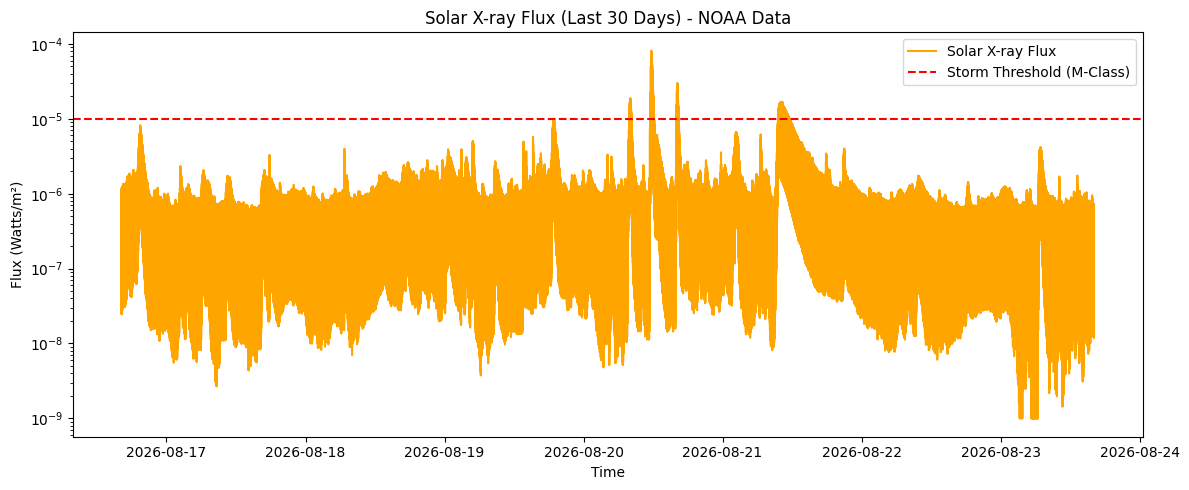

In [14]:


# 7. ทำนายและประเมินผล
y_pred = model.predict(X_test)
print("\n--- ผลลัพธ์การทำนายพายุสุริยะ ---")
print(f"ความแม่นยำ (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, zero_division=0))

# 8. วาดกราฟเพื่อเอาไปใส่ใน Pitch Deck
plt.figure(figsize=(12, 5))
plt.plot(df['time_tag'], df['flux'], label='Solar X-ray Flux', color='orange')
plt.axhline(y=1e-5, color='red', linestyle='--', label='Storm Threshold (M-Class)')
plt.yscale('log')
plt.title("Solar X-ray Flux (Last 30 Days) - NOAA Data")
plt.xlabel("Time")
plt.ylabel("Flux (Watts/m²)")
plt.legend()
plt.tight_layout()
plt.savefig('solar_storm_graph.png') # บันทึกภาพกราฟไว้ใส่สไลด์ได้เลย!
print("\nบันทึกกราฟเป็นไฟล์ 'solar_storm_graph.png' สำเร็จแล้ว!")